PREDICTOR DEL GÉNERO MUSICAL DE UNA CANCIÓN USANDO MACHINE LEARNING: Datos Tabulares

Preparación de los datos

In [ ]:
# Nos conectamos con Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

tracks = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/tracks.csv", header=[0,1], index_col=0)
echonest = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/echonest.csv", header=[0,1,2], index_col=0)
genres = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/genres.csv")
features = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/features.csv", header = [0,1,2], index_col = 0)

In [ ]:
tracks_small = tracks[tracks[("set","subset")] == "small"]
ids_small = tracks_small.index

(8000, 52)

In [ ]:
features_small = features.loc[ids_small]

(8000, 518)

In [ ]:
features_small.to_csv('features_small.csv', index=False)

from google.colab import files
files.download('features_small.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
objetivo = tracks_small[[("track", "genre_top")]]

(8000, 1)

In [ ]:
objetivo.to_csv('objetivo.csv', index=False)

from google.colab import files
files.download('objetivo.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modelo XGBoost

In [ ]:
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

X_full = features_small.copy()

X_full.columns = ['_'.join(map(str, col)).strip() for col in X_full.columns.values]

y_full = objetivo
le_full = LabelEncoder()
y_full_num = le_full.fit_transform(y_full)

# 1. Primera división: Separamos el Test final (dejamos un 15% intocable)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full_num, test_size=0.15, random_state=42, stratify=y_full_num
)

# 2. Segunda división: El 85% restante (temp) lo dividimos en Entrenamiento y Validación
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1764, random_state=42, stratify=y_temp
)

print(f"Dimensiones de Entrenamiento: {X_train.shape}")
print(f"Dimensiones de Validación:    {X_val.shape}")
print(f"Dimensiones de Test:          {X_test.shape}")

Dimensiones de Entrenamiento: (5600, 518)
Dimensiones de Validación:    (1200, 518)
Dimensiones de Test:          (1200, 518)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

opciones_profundidad = [8]
opciones_learning_rate = [0.2]

mejor_precision = 0
mejores_parametros = {}
mejor_modelo = None

print("Iniciando búsqueda de hiperparámetros en el conjunto de VALIDACIÓN...\n")

# Probamos todas las combinaciones posibles
for profundidad in opciones_profundidad:
    for lr in opciones_learning_rate:

        # 1. Configuramos el modelo con la combinación actual
        modelo_prueba = xgb.XGBClassifier(
            n_estimators=150,
            max_depth=profundidad,
            learning_rate=lr,
            subsample=0.8,
            colsample_bytree=0.5,
            random_state=42,
            n_jobs=-1,
            tree_method='hist'
        )

        # 2. Entrenamos en el set de Entrenamiento
        modelo_prueba.fit(X_train, y_train)

        # 3. Evaluamos en el set de Validación (¡Nunca en el de Test!)
        y_pred_val = modelo_prueba.predict(X_val)
        precision_val = accuracy_score(y_val, y_pred_val)

        print(f"Probando max_depth={profundidad}, learning_rate={lr} -> Precisión Val: {precision_val:.4f}")

        # 4. Guardamos el mejor modelo
        if precision_val > mejor_precision:
            mejor_precision = precision_val
            mejores_parametros = {'max_depth': profundidad, 'learning_rate': lr}
            mejor_modelo = modelo_prueba

print(f"\n🏆 ¡Búsqueda completada!")
print(f"Los mejores hiperparámetros son: {mejores_parametros} con un {mejor_precision*100:.2f}% en Validación.")

y_pred_test = mejor_modelo.predict(X_test)
precision_test = accuracy_score(y_test, y_pred_test)

print(f"\n🚀 Precisión Final en el conjunto de TEST (Datos nunca antes vistos): {precision_test*100:.2f}%")

Iniciando búsqueda de hiperparámetros en el conjunto de VALIDACIÓN...

Probando max_depth=8, learning_rate=0.2 -> Precisión Val: 0.6458

🏆 ¡Búsqueda completada!
Los mejores hiperparámetros son: {'max_depth': 8, 'learning_rate': 0.2} con un 64.58% en Validación.

🚀 Precisión Final en el conjunto de TEST (Datos nunca antes vistos): 61.42%



📊 Generando la Matriz de Confusión del mejor modelo...


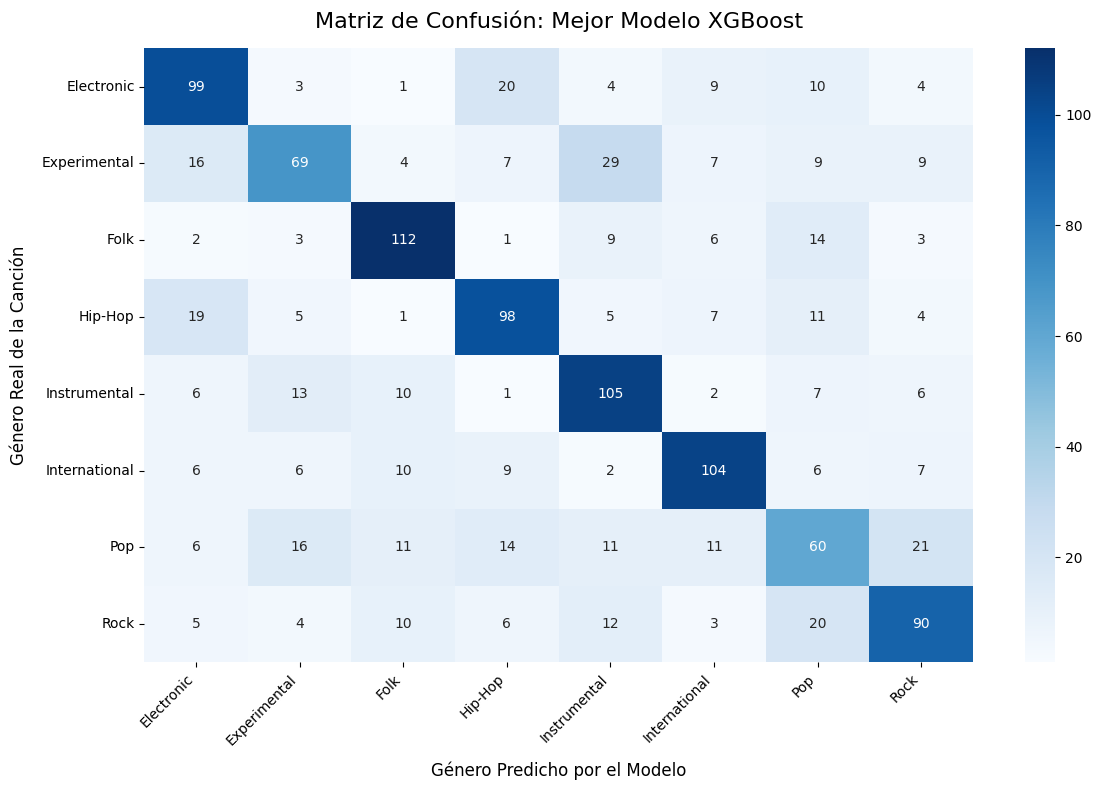

In [ ]:
# Matriz de Confusión

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("\n📊 Generando la Matriz de Confusión del mejor modelo...")

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(12, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_full.classes_,
            yticklabels=le_full.classes_)

plt.title('Matriz de Confusión: Mejor Modelo XGBoost', fontsize=16, pad=15)
plt.xlabel('Género Predicho por el Modelo', fontsize=12, labelpad=10)
plt.ylabel('Género Real de la Canción', fontsize=12, labelpad=10)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Guardar el modelo

import joblib

joblib.dump(mejor_modelo, "/content/drive/MyDrive/ProyectoIA/modelo_xgboost.pkl")
print("Modelo guardado como modelo_xgboost.PKL")

# modelo_cargado = joblib.load('mejor_modelo_entrenado.pkl')

Modelo guardado como modelo_xgboost.PKL


In [ ]:
import librosa
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def extraer_518_caracteristicas(ruta_mp3):
    try:
        y, sr = librosa.load(ruta_mp3, sr=22050, duration=30)

        feat = {}

        def agregar_stats(nombre, datos):
            feat[f'{nombre}_mean'] = np.mean(datos, axis=1)
            feat[f'{nombre}_std'] = np.std(datos, axis=1)
            feat[f'{nombre}_skew'] = skew(datos, axis=1)
            feat[f'{nombre}_kurtosis'] = kurtosis(datos, axis=1)
            feat[f'{nombre}_median'] = np.median(datos, axis=1)
            feat[f'{nombre}_min'] = np.min(datos, axis=1)
            feat[f'{nombre}_max'] = np.max(datos, axis=1)

        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12)
        agregar_stats('chroma_stft', chroma)

        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
        agregar_stats('tonnetz', tonnetz)

        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        agregar_stats('mfcc', mfcc)

        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        agregar_stats('spectral_centroid', centroid)

        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        agregar_stats('spectral_bandwidth', bandwidth)

        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        agregar_stats('spectral_rolloff', rolloff)

        contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6)
        agregar_stats('spectral_contrast', contrast)

        zcr = librosa.feature.zero_crossing_rate(y)
        agregar_stats('zcr', zcr)

        data_final = {}
        for k, v in feat.items():
            if isinstance(v, np.ndarray) and v.ndim > 0:
                for i, val in enumerate(v):
                    nombre_col = f"{k}_{i+1:02d}"
                    data_final[nombre_col] = val
            else:
                data_final[k] = v

        return pd.DataFrame([data_final])

    except Exception as e:
        print(f"Error: {e}")
        return None

ruta_nueva_cancion = "/content/drive/MyDrive/ProyectoIA/Tonight_Again.mp3"
X_nueva = extraer_518_caracteristicas(ruta_nueva_cancion)

if X_nueva is not None:
    try:
        X_nueva = X_nueva.reindex(columns=X_train.columns, fill_value=0)

        prediccion_idx = mejor_modelo.predict(X_nueva)[0]
        probabilidades = mejor_modelo.predict_proba(X_nueva)[0]

        print(f"\n--- Resultado para: {ruta_nueva_cancion} ---")

        if 'label_encoder' in locals() or 'le' in locals():
            genero_nombre = label_encoder.inverse_transform([prediccion_idx])[0]
            print(f"🎸 Género Predicho: {genero_nombre}")
        else:
            print(f"🔢 Clase Predicha (ID): {prediccion_idx}")

        print(f"📊 Confianza: {np.max(probabilidades)*100:.2f}%")

    except Exception as e:
        print(f"Error en la alineación de datos: {e}")


--- Resultado para: /content/drive/MyDrive/ProyectoIA/Tonight_Again.mp3 ---
🔢 Clase Predicha (ID): 4
📊 Confianza: 42.82%


Modelo SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

print("1. Iniciando el escalado de datos (OBLIGATORIO para SVM)...")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente.\n")

opciones_C = [50, 100, 1000]
opciones_gamma = ['scale', 'auto']

opciones_C = [50]
opciones_gamma = ['scale']

mejor_precision_svm = 0
mejores_parametros_svm = {}
mejor_modelo_svm = None

print("2. Iniciando búsqueda de hiperparámetros SVM en VALIDACIÓN...\n")

for valor_c in opciones_C:
    for valor_gamma in opciones_gamma:

        modelo_prueba_svm = SVC(
            kernel='rbf',
            C=valor_c,
            gamma=valor_gamma,
            random_state=42
        )

        modelo_prueba_svm.fit(X_train_scaled, y_train)

        y_pred_val = modelo_prueba_svm.predict(X_val_scaled)
        precision_val = accuracy_score(y_val, y_pred_val)

        print(f"Probando C={valor_c:<4}, gamma={str(valor_gamma):<5} -> Precisión Val: {precision_val:.4f}")

        if precision_val > mejor_precision_svm:
            mejor_precision_svm = precision_val
            mejores_parametros_svm = {'C': valor_c, 'gamma': valor_gamma}
            mejor_modelo_svm = modelo_prueba_svm

print(f"\n🏆 ¡Búsqueda completada!")
print(f"Mejores hiperparámetros SVM: {mejores_parametros_svm} con un {mejor_precision_svm*100:.2f}% en Validación.")

y_pred_test_svm = mejor_modelo_svm.predict(X_test_scaled)
precision_test_svm = accuracy_score(y_test, y_pred_test_svm)

print(f"\n🚀 Precisión Final SVM en el conjunto de TEST: {precision_test_svm*100:.2f}%")

1. Iniciando el escalado de datos (OBLIGATORIO para SVM)...
Datos escalados correctamente.

2. Iniciando búsqueda de hiperparámetros SVM en VALIDACIÓN...

Probando C=50  , gamma=scale -> Precisión Val: 0.6283

🏆 ¡Búsqueda completada!
Mejores hiperparámetros SVM: {'C': 50, 'gamma': 'scale'} con un 62.83% en Validación.

🚀 Precisión Final SVM en el conjunto de TEST: 62.25%


In [ ]:
import joblib

lista_columnas = list(X_train.columns)
joblib.dump(lista_columnas, '/content/drive/MyDrive/ProyectoIA/columnas_oficiales.pkl')

['/content/drive/MyDrive/ProyectoIA/columnas_oficiales.pkl']

In [ ]:
import joblib

archivo_modelo = '/content/drive/MyDrive/ProyectoIA/modelo_svm.pkl'
archivo_escalador = '/content/drive/MyDrive/ProyectoIA/escalador_svm.pkl'

joblib.dump(mejor_modelo_svm, archivo_modelo)

joblib.dump(scaler, archivo_escalador)

print(f"✅ Modelo guardado en: {archivo_modelo}")
print(f"✅ Escalador guardado en: {archivo_escalador}")

✅ Modelo guardado en: /content/drive/MyDrive/ProyectoIA/modelo_svm.pkl
✅ Escalador guardado en: /content/drive/MyDrive/ProyectoIA/escalador_svm.pkl



📊 Generando la Matriz de Confusión para el modelo SVM...


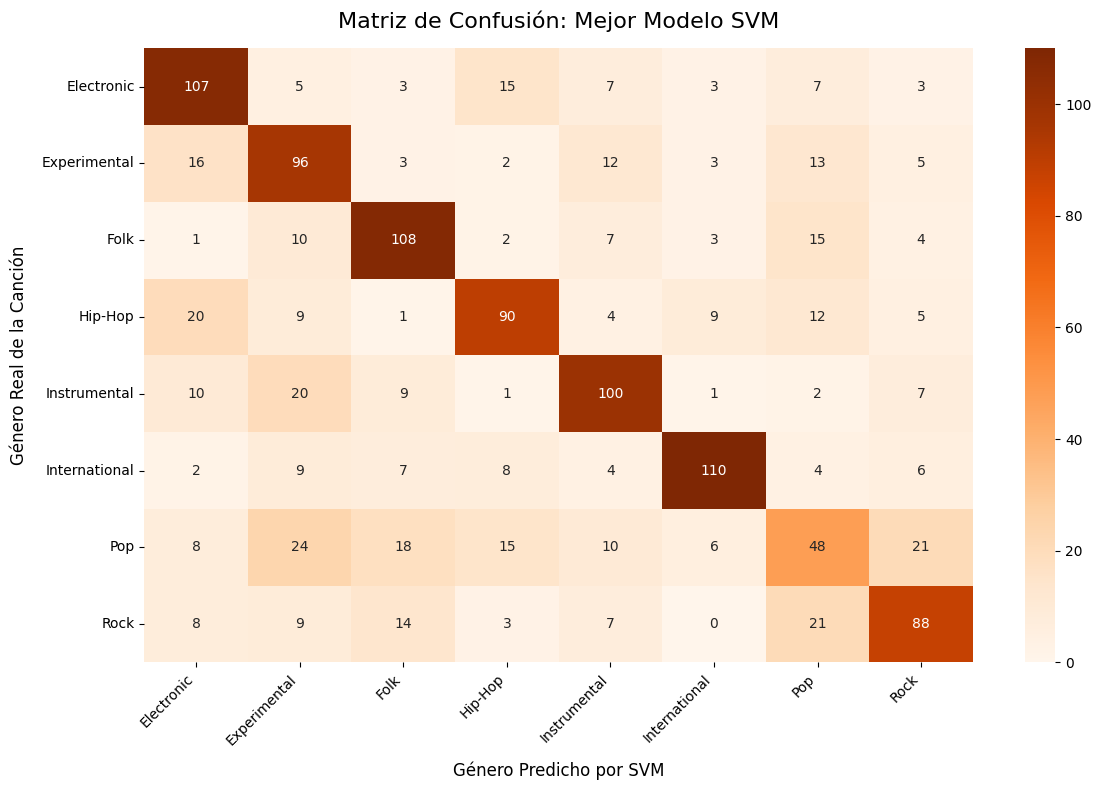

In [ ]:
# Matriz de Confusión

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("\n📊 Generando la Matriz de Confusión para el modelo SVM...")

y_pred_test_svm = mejor_modelo_svm.predict(X_test_scaled)

cm_svm = confusion_matrix(y_test, y_pred_test_svm)

plt.figure(figsize=(12, 8))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_full.classes_,
            yticklabels=le_full.classes_)

plt.title('Matriz de Confusión: Mejor Modelo SVM', fontsize=16, pad=15)
plt.xlabel('Género Predicho por SVM', fontsize=12, labelpad=10)
plt.ylabel('Género Real de la Canción', fontsize=12, labelpad=10)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 7. Mostramos el gráfico
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import numpy as np
import pandas as pd

path_modelo = '/content/drive/MyDrive/ProyectoIA/modelo_svm.pkl'
path_escalador = '/content/drive/MyDrive/ProyectoIA/escalador_svm.pkl'

modelo_svm = joblib.load(path_modelo)
scaler_svm = joblib.load(path_escalador)

def predecir_genero_svm(ruta_audio):
    print(f"--- Procesando: {ruta_audio} ---")

    df_features = extraer_518_caracteristicas(ruta_audio)

    if df_features is not None:
        try:
            df_alineado = df_features.reindex(columns=X_train.columns, fill_value=0)

            features_escaladas = scaler_svm.transform(df_alineado)

            prediccion_idx = modelo_svm.predict(features_escaladas)[0]

            genero_nombre = le_full.inverse_transform([prediccion_idx])[0]

            print(f"\n✨ RESULTADO FINAL ✨")
            print(f"La canción suena a: {genero_nombre.upper()}")

        except Exception as e:
            print(f"❌ Error durante la predicción: {e}")
    else:
        print("❌ No se pudieron extraer características del audio.")

ruta_test = "/content/drive/MyDrive/ProyectoIA/The_Fog_Trey_Xavier_Rod_Kim.mp3"
predecir_genero_svm(ruta_test)

--- Procesando: /content/drive/MyDrive/ProyectoIA/The_Fog_Trey_Xavier_Rod_Kim.mp3 ---

✨ RESULTADO FINAL ✨
La canción suena a: EXPERIMENTAL


Modelo KNN

1. Iniciando búsqueda de hiperparámetros para k-NN en VALIDACIÓN...

Probando k=3 , weights=uniform  -> Precisión Val: 0.4400
Probando k=3 , weights=distance -> Precisión Val: 0.4550
Probando k=5 , weights=uniform  -> Precisión Val: 0.4600
Probando k=5 , weights=distance -> Precisión Val: 0.4775
Probando k=7 , weights=uniform  -> Precisión Val: 0.4733
Probando k=7 , weights=distance -> Precisión Val: 0.4800
Probando k=9 , weights=uniform  -> Precisión Val: 0.4892
Probando k=9 , weights=distance -> Precisión Val: 0.4950
Probando k=11, weights=uniform  -> Precisión Val: 0.4683
Probando k=11, weights=distance -> Precisión Val: 0.4825
Probando k=15, weights=uniform  -> Precisión Val: 0.4683
Probando k=15, weights=distance -> Precisión Val: 0.4717
Probando k=21, weights=uniform  -> Precisión Val: 0.4625
Probando k=21, weights=distance -> Precisión Val: 0.4700

🏆 ¡Búsqueda completada!
Mejores hiperparámetros k-NN: {'k': 9, 'weights': 'distance'} con un 49.50% en Validación.

🚀 Evaluando en e

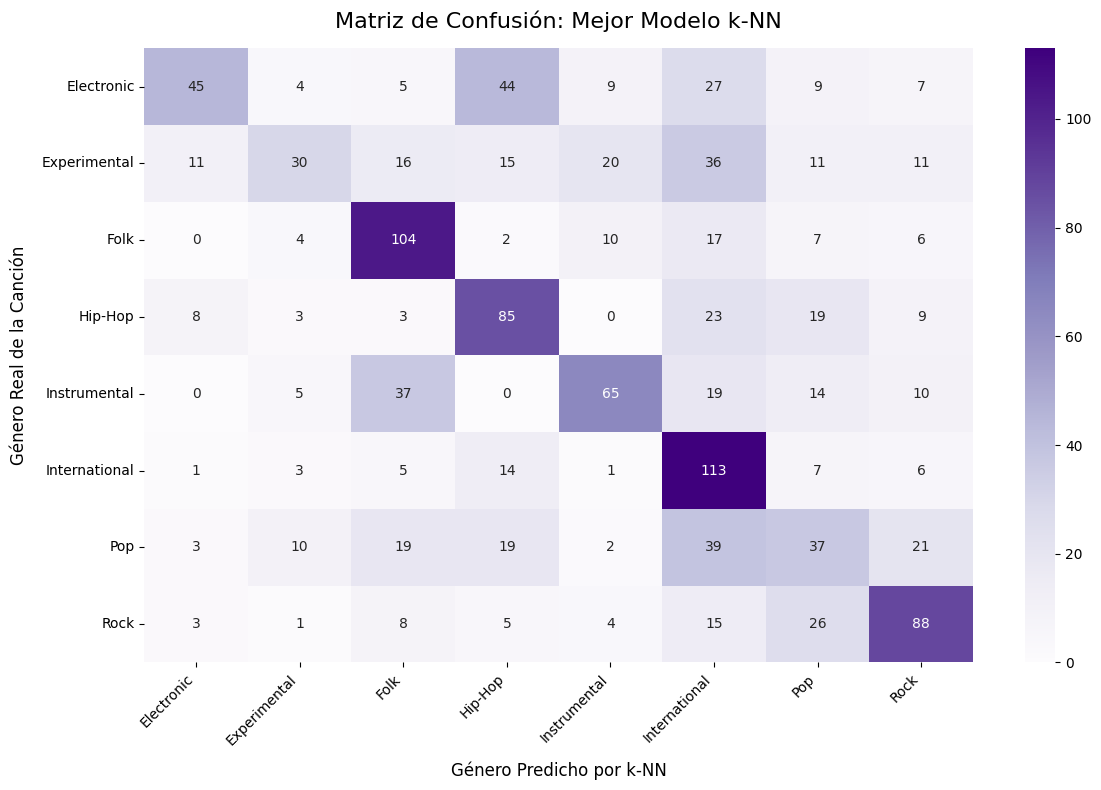

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Iniciando búsqueda de hiperparámetros para k-NN en VALIDACIÓN...\n")

opciones_k = [3, 5, 7, 9, 11, 15, 21]
opciones_pesos = ['uniform', 'distance']

mejor_precision_knn = 0
mejores_parametros_knn = {}
mejor_modelo_knn = None


for k in opciones_k:
    for peso in opciones_pesos:

        # 1. Configuramos el modelo
        modelo_prueba_knn = KNeighborsClassifier(
            n_neighbors=k,
            weights=peso,
            n_jobs=-1
        )

        # 2. Entrenamos (k-NN no hace casi nada aquí, solo guarda los datos)
        modelo_prueba_knn.fit(X_train_scaled, y_train)

        # 3. Evaluamos en el set de VALIDACIÓN
        y_pred_val = modelo_prueba_knn.predict(X_val_scaled)
        precision_val = accuracy_score(y_val, y_pred_val)

        print(f"Probando k={k:<2}, weights={peso:<8} -> Precisión Val: {precision_val:.4f}")

        # 4. Guardamos el mejor modelo
        if precision_val > mejor_precision_knn:
            mejor_precision_knn = precision_val
            mejores_parametros_knn = {'k': k, 'weights': peso}
            mejor_modelo_knn = modelo_prueba_knn

print(f"\n🏆 ¡Búsqueda completada!")
print(f"Mejores hiperparámetros k-NN: {mejores_parametros_knn} con un {mejor_precision_knn*100:.2f}% en Validación.")

print("\n🚀 Evaluando en el conjunto de TEST...")
y_pred_test_knn = mejor_modelo_knn.predict(X_test_scaled)
precision_test_knn = accuracy_score(y_test, y_pred_test_knn)

print(f"Precisión Final k-NN en TEST: {precision_test_knn*100:.2f}%")

print("\n📊 Generando la Matriz de Confusión para k-NN...")
cm_knn = confusion_matrix(y_test, y_pred_test_knn)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=le_full.classes_,
            yticklabels=le_full.classes_)

plt.title('Matriz de Confusión: Mejor Modelo k-NN', fontsize=16, pad=15)
plt.xlabel('Género Predicho por k-NN', fontsize=12, labelpad=10)
plt.ylabel('Género Real de la Canción', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Regresión Logística

1. Iniciando búsqueda de hiperparámetros para Regresión Logística en VALIDACIÓN...

Probando C=0.001, solver=lbfgs   -> Precisión Val: 0.5617
Probando C=0.005, solver=lbfgs   -> Precisión Val: 0.5858
Probando C=0.01 , solver=lbfgs   -> Precisión Val: 0.5850
Probando C=0.05 , solver=lbfgs   -> Precisión Val: 0.5758
Probando C=0.1  , solver=lbfgs   -> Precisión Val: 0.5617
Probando C=1    , solver=lbfgs   -> Precisión Val: 0.5558

🏆 ¡Búsqueda completada!
Mejores hiperparámetros Regresión Logística: {'C': 0.005, 'solver': 'lbfgs'} con un 58.58% en Validación.

🚀 Evaluando en el conjunto de TEST...
Precisión Final Regresión Logística en TEST: 58.50%

📊 Generando la Matriz de Confusión para Regresión Logística...


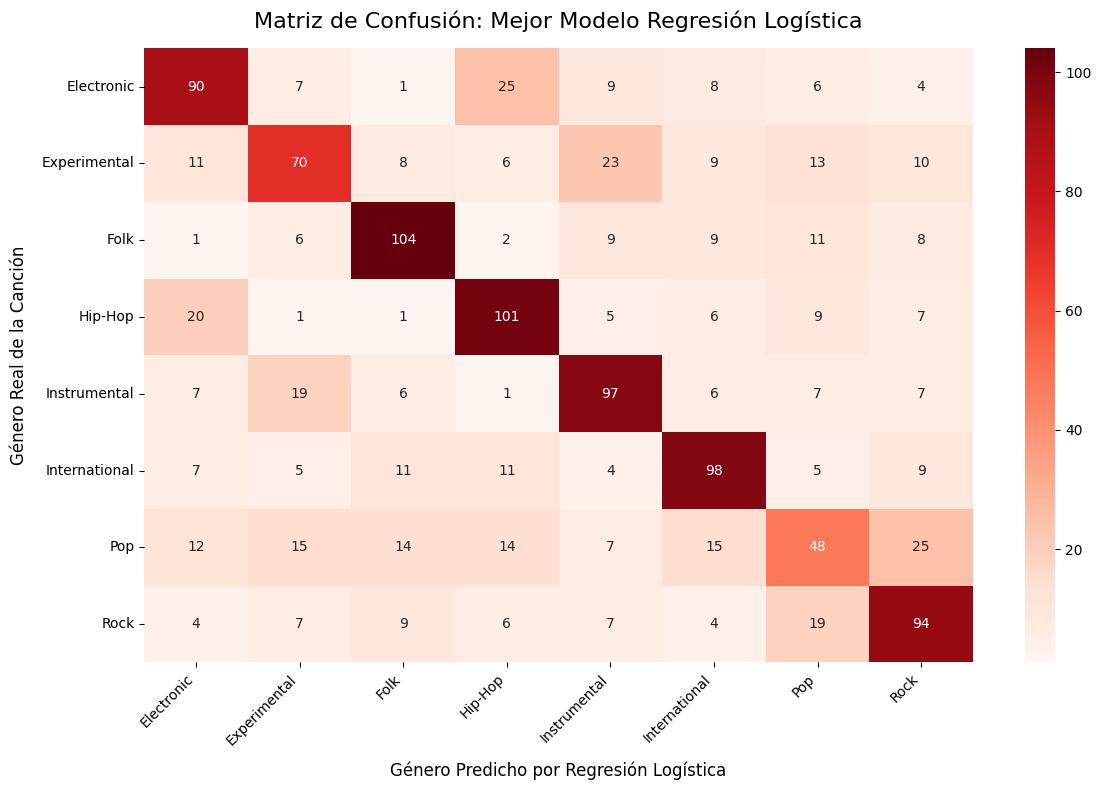

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("1. Iniciando búsqueda de hiperparámetros para Regresión Logística en VALIDACIÓN...\n")


opciones_C = [0.001, 0.005, 0.01, 0.05, 0.1, 1]
opciones_solver = ['lbfgs']

mejor_precision_lr = 0
mejores_parametros_lr = {}
mejor_modelo_lr = None

for c in opciones_C:
    for solver in opciones_solver:

        # 1. Configuramos el modelo
        modelo_prueba_lr = LogisticRegression(
            C=c,
            solver=solver,
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )

        # 2. Entrenamos
        modelo_prueba_lr.fit(X_train_scaled, y_train)

        # 3. Evaluamos en validación
        y_pred_val = modelo_prueba_lr.predict(X_val_scaled)
        precision_val = accuracy_score(y_val, y_pred_val)

        print(f"Probando C={c:<5}, solver={solver:<7} -> Precisión Val: {precision_val:.4f}")

        # 4. Guardamos el mejor modelo
        if precision_val > mejor_precision_lr:
            mejor_precision_lr = precision_val
            mejores_parametros_lr = {'C': c, 'solver': solver}
            mejor_modelo_lr = modelo_prueba_lr

print(f"\n🏆 ¡Búsqueda completada!")
print(f"Mejores hiperparámetros Regresión Logística: {mejores_parametros_lr} con un {mejor_precision_lr*100:.2f}% en Validación.")

print("\n🚀 Evaluando en el conjunto de TEST...")
y_pred_test_lr = mejor_modelo_lr.predict(X_test_scaled)
precision_test_lr = accuracy_score(y_test, y_pred_test_lr)

print(f"Precisión Final Regresión Logística en TEST: {precision_test_lr*100:.2f}%")

print("\n📊 Generando la Matriz de Confusión para Regresión Logística...")
cm_lr = confusion_matrix(y_test, y_pred_test_lr)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Reds',
            xticklabels=le_full.classes_,
            yticklabels=le_full.classes_)

plt.title('Matriz de Confusión: Mejor Modelo Regresión Logística', fontsize=16, pad=15)
plt.xlabel('Género Predicho por Regresión Logística', fontsize=12, labelpad=10)
plt.ylabel('Género Real de la Canción', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()